In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.23M/2.23M [00:00<00:00, 3.02MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1


In [2]:
import kagglehub
print("Версия:", kagglehub.__version__)

Версия: 1.0.2


In [3]:
import kagglehub

path = kagglehub.dataset_download("muthuj7/weather-dataset")
print("Path:", path)

Path: /root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1


In [4]:
import os

path = "/root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1"
files = os.listdir(path)
print("Файлы в датасете:", files)

Файлы в датасете: ['weatherHistory.csv']


In [5]:
import pandas as pd

csv_file = [f for f in files if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Размер:", df.shape)
print()
print(df.head())
print()
df.info()

Размер: (96453, 12)

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0   

In [6]:
import urllib.request
import os

url = "https://zenodo.org/records/17789545/files/RusWeather-GF.zip?download=1"
zip_path = "/app/RusWeather-GF.zip"

print("Скачиваем... Это может занять 1–3 минуты.")
urllib.request.urlretrieve(url, zip_path)
print("Готово. Размер файла:", os.path.getsize(zip_path) / (1024*1024), "МБ")

Скачиваем... Это может занять 1–3 минуты.
Готово. Размер файла: 71.53017902374268 МБ


In [7]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/app/")

print("Распаковано. Файлы в /app:")
print(os.listdir("/app"))

Распаковано. Файлы в /app:
['.dockerignore', '.ipynb_checkpoints', '.Trash-0', '01_intro.ipynb', '03_titanic_eda.ipynb', 'docker-compose.yml', 'Dockerfile', 'requirements.txt', 'RusWeather-GF', 'RusWeather-GF.zip', 'Untitled.ipynb']


In [8]:
import pandas as pd

csv_path = "/app/RusWeather-GF_1980-2023.csv"
df = pd.read_csv(csv_path)

print("Размер:", df.shape)
print()
print(df.head())
print()
df.info()

FileNotFoundError: [Errno 2] No such file or directory: '/app/RusWeather-GF_1980-2023.csv'

In [9]:
import os

folder = "/app/RusWeather-GF"
print("Файлы внутри:", os.listdir(folder))

Файлы внутри: ['LICENSE.txt', 'metadata.json', 'README.txt', 'RusWeather-GF_1980-2023.csv']


In [10]:
import pandas as pd

csv_path = "/app/RusWeather-GF/RusWeather-GF_1980-2023.csv"  # ← проверь имя!
df = pd.read_csv(csv_path)

print("Размер:", df.shape)
print()
print(df.head())
print()
df.info()

Размер: (8893613, 10)

   station_id        date  year  month  day  temperature  precipitation   lat  \
0       20046  1980-01-01  1980      1    1        -24.5            1.7  80.6   
1       20046  1980-01-02  1980      1    2        -21.8            0.5  80.6   
2       20046  1980-01-03  1980      1    3        -24.3            0.5  80.6   
3       20046  1980-01-04  1980      1    4        -24.0            5.2  80.6   
4       20046  1980-01-05  1980      1    5        -18.1            3.7  80.6   

    lon  elevation  
0  58.0       21.0  
1  58.0       21.0  
2  58.0       21.0  
3  58.0       21.0  
4  58.0       21.0  

<class 'pandas.DataFrame'>
RangeIndex: 8893613 entries, 0 to 8893612
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   station_id     int64  
 1   date           str    
 2   year           int64  
 3   month          int64  
 4   day            int64  
 5   temperature    float64
 6   precipitation  float64
 7   lat 

In [11]:
import json

with open("/app/RusWeather-GF/metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

# Посмотрим структуру
print(type(meta))
print(json.dumps(meta, ensure_ascii=False, indent=2)[:2000])

<class 'dict'>
{
  "dataset_name": "RusWeather-GF",
  "full_name": "Russian Weather - Gap-Filled",
  "title": "Gap-Filled Daily Weather Dataset for Russia (1980-2023): Temperature and Precipitation from 593 Stations",
  "version": "1.0",
  "date_created": "2025-01-01",
  "authors": [
    {
      "name": "Tkachenko, M.A.",
      "affiliation": "V.V. Dokuchaev Soil Science Institute, Moscow, Russia",
      "address": "Pyzhevsky Lane 7, Moscow, Russia",
      "email": "usa4eva.m@mail.ru"
    },
    {
      "name": "Fomin, D.S.",
      "affiliation": "V.V. Dokuchaev Soil Science Institute, Moscow, Russia",
      "address": "Pyzhevsky Lane 7, Moscow, Russia"
    }
  ],
  "description": "Daily temperature and precipitation observations from 593 Russian weather stations with 100% gap-filling coverage and FABDEM elevation data.",
  "keywords": [
    "RusWeather-GF",
    "meteorology",
    "Russia",
    "gap-filled",
    "temperature",
    "precipitation",
    "daily data",
    "weather station

In [12]:
# Найдём станции рядом с Москвой
stations_near_moscow = df[
    (df["lat"].between(55.0, 56.5)) & (df["lon"].between(37.0, 38.5))
]["station_id"].unique()

print("Станции рядом с Москвой:", stations_near_moscow)

Станции рядом с Москвой: [27612]


In [13]:
MOSCOW_ID = 27612

df_city = df[df["station_id"] == MOSCOW_ID].copy()
df_city = df_city.sort_values("date").reset_index(drop=True)

print("Строк по Москве:", len(df_city))
print("Дата от:", df_city["date"].min())
print("Дата до: ", df_city["date"].max())
print()
print(df_city.head())

Строк по Москве: 16071
Дата от: 1980-01-01
Дата до:  2023-12-31

   station_id        date  year  month  day  temperature  precipitation  \
0       27612  1980-01-01  1980      1    1         -6.8            2.2   
1       27612  1980-01-02  1980      1    2         -3.3            0.9   
2       27612  1980-01-03  1980      1    3         -2.9            2.6   
3       27612  1980-01-04  1980      1    4         -5.4            6.9   
4       27612  1980-01-05  1980      1    5         -5.3            4.6   

     lat    lon  elevation  
0  55.83  37.62      147.0  
1  55.83  37.62      147.0  
2  55.83  37.62      147.0  
3  55.83  37.62      147.0  
4  55.83  37.62      147.0  


In [14]:
df_city["date"] = pd.to_datetime(df_city["date"])
df_city = df_city.sort_values("date").reset_index(drop=True)

print("Тип date:", df_city["date"].dtype)
print("Пропущено дней:", (df_city["date"].diff().dt.days > 1).sum())
print()
print("Температура — статистика:")
print(df_city["temperature"].describe().round(2))

Тип date: datetime64[us]
Пропущено дней: 0

Температура — статистика:
count    16071.00
mean         6.12
std         10.47
min        -29.00
25%         -1.20
50%          6.10
75%         15.10
max         30.80
Name: temperature, dtype: float64


In [15]:
# Агрегируем данные по месяцам, взяв среднюю температуру
df_monthly = df_city.set_index('date').resample('MS')['temperature'].mean().reset_index()

# Переименовываем колонки для Prophet
df_monthly = df_monthly.rename(columns={'date': 'ds', 'temperature': 'y'})

print(df_monthly.head())
print(f"Всего месяцев в датасете: {len(df_monthly)}")

          ds          y
0 1980-01-01 -11.312903
1 1980-02-01  -7.151724
2 1980-03-01  -6.370968
3 1980-04-01   5.846667
4 1980-05-01   8.370968
Всего месяцев в датасете: 528


In [16]:
from prophet import Prophet

# Создаем и обучаем модель
model = Prophet(
    yearly_seasonality=True,  # Учитываем годовую сезонность
    weekly_seasonality=False, # Для месячных данных недельная сезонность не нужна
    daily_seasonality=False,
    interval_width=0.95       # 95% доверительный интервал
)
model.fit(df_monthly)

ModuleNotFoundError: No module named 'prophet'

In [1]:
from prophet import Prophet
print("Prophet работает")

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet работает


In [1]:
import plotly
import ipywidgets
from prophet import Prophet
print("plotly:", plotly.__version__)
print("ipywidgets:", ipywidgets.__version__)
print("Prophet готов")

plotly: 7.1.0
ipywidgets: 8.1.9
Prophet готов


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from prophet import Prophet

# Загружаем данные
df = pd.read_csv("/app/RusWeather-GF/RusWeather-GF_1980-2023.csv")

# Фильтруем Москву (ID = 27612)
df_city = df[df["station_id"] == 27612].copy()
df_city["date"] = pd.to_datetime(df_city["date"])
df_city = df_city.sort_values("date").reset_index(drop=True)

print("Строк по Москве:", len(df_city))
print("Дата от:", df_city["date"].min())
print("Дата до: ", df_city["date"].max())

Строк по Москве: 16071
Дата от: 1980-01-01 00:00:00
Дата до:  2023-12-31 00:00:00


In [3]:
# Среднемесячная температура
df_monthly = df_city.set_index("date").resample("MS")["temperature"].mean().reset_index()
df_monthly = df_monthly.rename(columns={"date": "ds", "temperature": "y"})

print("Всего месяцев:", len(df_monthly))
print()
print("Первые 5:")
print(df_monthly.head())
print()
print("Последние 5:")
print(df_monthly.tail())

Всего месяцев: 528

Первые 5:
          ds          y
0 1980-01-01 -11.312903
1 1980-02-01  -7.151724
2 1980-03-01  -6.370968
3 1980-04-01   5.846667
4 1980-05-01   8.370968

Последние 5:
            ds          y
523 2023-08-01  19.661290
524 2023-09-01  15.036667
525 2023-10-01   5.483871
526 2023-11-01   0.766667
527 2023-12-01  -4.454839


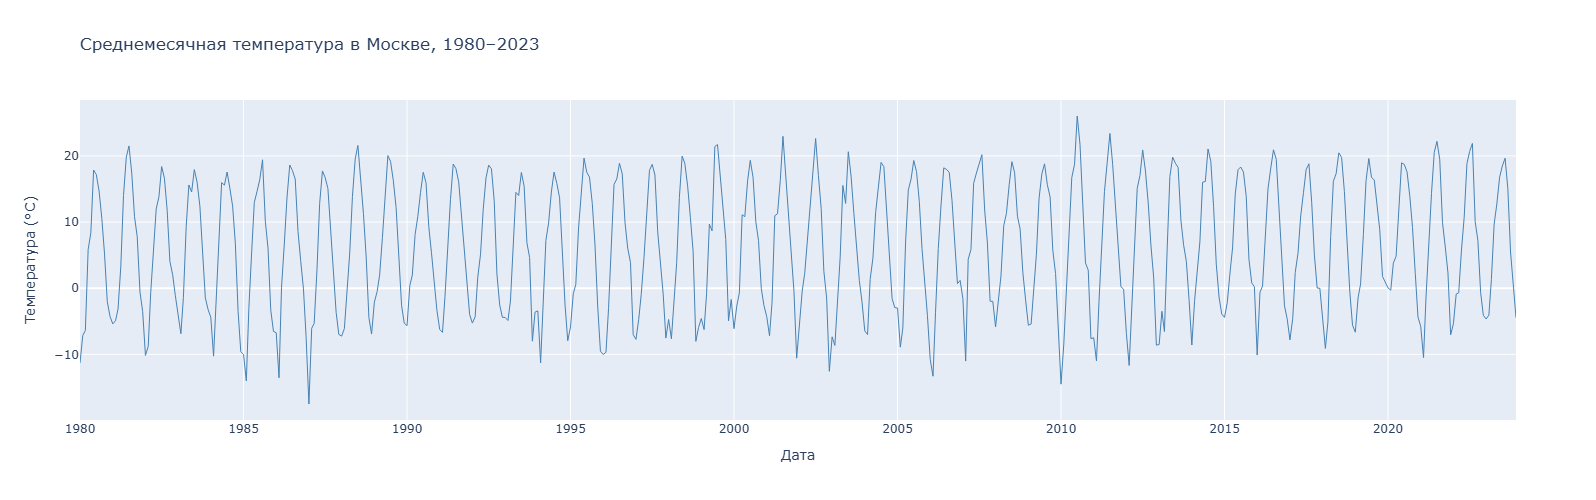

In [4]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_monthly["ds"],
    y=df_monthly["y"],
    mode="lines",
    name="Среднемесячная температура",
    line=dict(color="steelblue", width=1),
))
fig.update_layout(
    title="Среднемесячная температура в Москве, 1980–2023",
    xaxis_title="Дата",
    yaxis_title="Температура (°C)",
    hovermode="x unified",
    height=500,
)
fig.show()

In [5]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
)
model.fit(df_monthly)
print("Модель обучена")

13:32:17 - cmdstanpy - INFO - Chain [1] start processing
13:32:18 - cmdstanpy - INFO - Chain [1] done processing


Модель обучена


In [6]:
# 84 месяца вперёд (7 лет × 12)
future = model.make_future_dataframe(periods=84, freq="MS")
forecast = model.predict(future)

# Прогноз на 2030 год
print("Прогноз на 2030 год:")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12).round(2))

Прогноз на 2030 год:
            ds   yhat  yhat_lower  yhat_upper
600 2030-01-01  -4.94       -9.81       -0.60
601 2030-02-01  -4.66       -9.19       -0.10
602 2030-03-01   0.50       -4.34        5.13
603 2030-04-01   8.20        3.74       12.99
604 2030-05-01  14.90       10.28       19.41
605 2030-06-01  18.85       14.10       23.45
606 2030-07-01  20.86       16.21       25.63
607 2030-08-01  19.00       14.41       23.71
608 2030-09-01  13.18        8.46       17.78
609 2030-10-01   7.26        2.79       11.89
610 2030-11-01   0.75       -3.78        5.35
611 2030-12-01  -2.98       -7.63        1.39


/tmp/ipykernel_23/2906055990.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12).round(2))


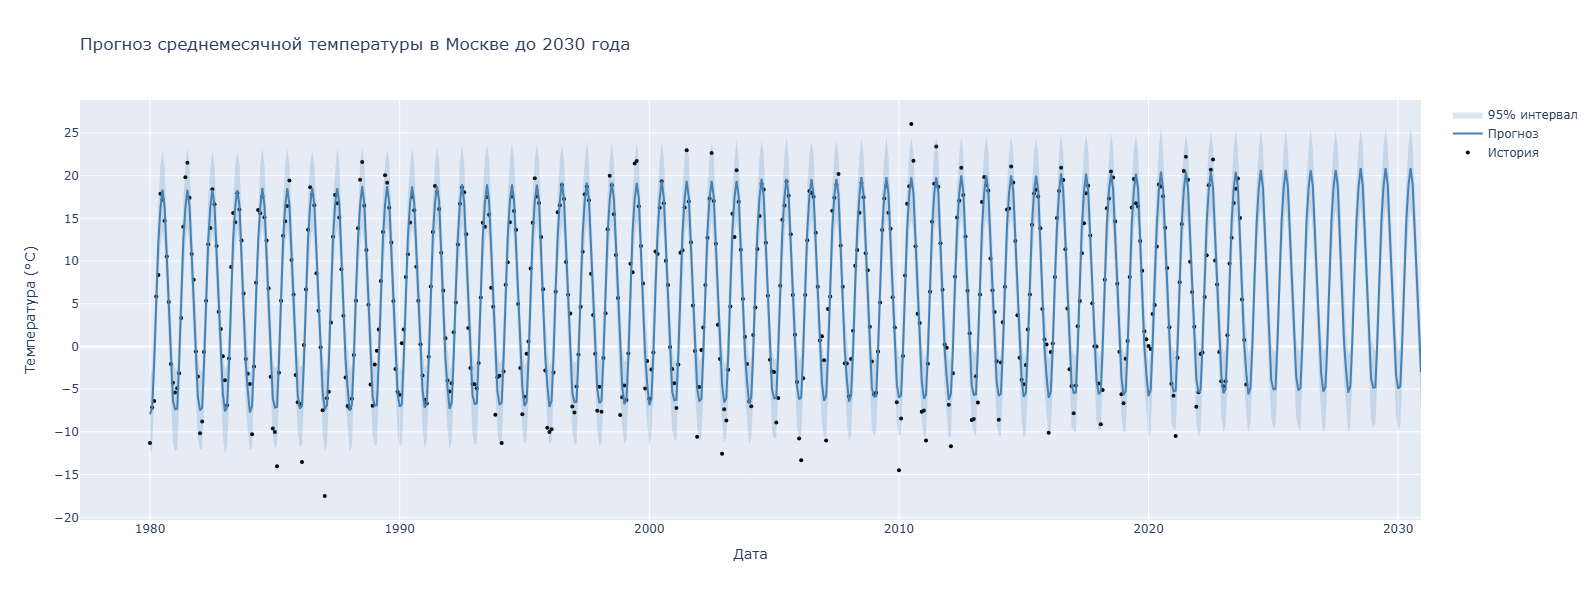

In [7]:
# Исторические данные
fig = go.Figure()

# Точки истории
fig.add_trace(go.Scatter(
    x=df_monthly["ds"],
    y=df_monthly["y"],
    mode="markers",
    name="История",
    marker=dict(color="black", size=4),
))

# Линия прогноза
fig.add_trace(go.Scatter(
    x=forecast["ds"],
    y=forecast["yhat"],
    mode="lines",
    name="Прогноз",
    line=dict(color="steelblue", width=2),
))

# Верхняя граница интервала
fig.add_trace(go.Scatter(
    x=forecast["ds"],
    y=forecast["yhat_upper"],
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip",
))

# Нижняя граница с заливкой
fig.add_trace(go.Scatter(
    x=forecast["ds"],
    y=forecast["yhat_lower"],
    mode="lines",
    line=dict(width=0),
    fill="tonexty",
    fillcolor="rgba(70,130,180,0.2)",
    name="95% интервал",
    hoverinfo="skip",
))

fig.update_layout(
    title="Прогноз среднемесячной температуры в Москве до 2030 года",
    xaxis_title="Дата",
    yaxis_title="Температура (°C)",
    hovermode="x unified",
    height=600,
)
fig.show()

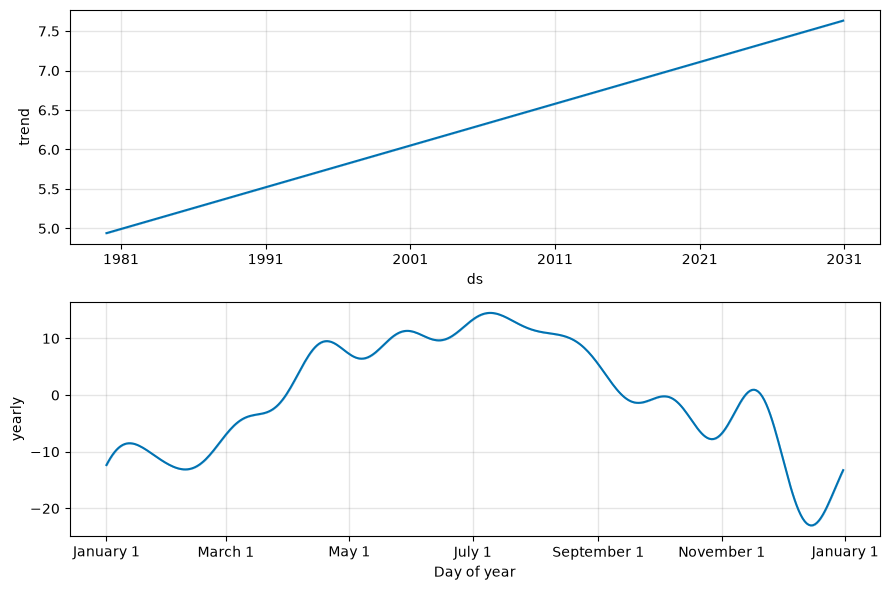

In [8]:
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [9]:
# Обучающая часть: 1980-01-01 — 2010-12-31
train = df_monthly[df_monthly["ds"] < "2011-01-01"].copy()

# Тестовая часть: 2011-01-01 — 2023-12-31
test = df_monthly[df_monthly["ds"] >= "2011-01-01"].copy()

print("Train:", len(train), "месяцев")
print("Test: ", len(test), "месяцев")
print()
print("Train от", train["ds"].min(), "до", train["ds"].max())
print("Test  от", test["ds"].min(), "до", test["ds"].max())

Train: 372 месяцев
Test:  156 месяцев

Train от 1980-01-01 00:00:00 до 2010-12-01 00:00:00
Test  от 2011-01-01 00:00:00 до 2023-12-01 00:00:00


In [10]:
model_bt = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
)
model_bt.fit(train)
print("Модель обучена на 1980–2010")

13:38:05 - cmdstanpy - INFO - Chain [1] start processing
13:38:05 - cmdstanpy - INFO - Chain [1] done processing


Модель обучена на 1980–2010


In [11]:
# Сколько месяцев предсказать
horizon = len(test)  # 156

# Будущие даты
future_bt = model_bt.make_future_dataframe(periods=horizon, freq="MS")

# Прогноз
forecast_bt = model_bt.predict(future_bt)

# Соединяем прогноз с реальными данными
merged = test.merge(
    forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left",
)

print("Прогноз на тестовый период:")
print(merged[["ds", "y", "yhat", "yhat_lower", "yhat_upper"]].head(10).round(2))

Прогноз на тестовый период:
          ds      y   yhat  yhat_lower  yhat_upper
0 2011-01-01  -7.49  -5.98      -10.80       -1.18
1 2011-02-01 -11.00  -5.94      -10.61       -1.38
2 2011-03-01  -2.03  -0.48       -5.60        4.32
3 2011-04-01   6.41   7.23        2.41       11.82
4 2011-05-01  14.59  13.82        9.20       18.82
5 2011-06-01  19.05  17.79       13.20       22.24
6 2011-07-01  23.40  19.91       15.70       24.97
7 2011-08-01  18.70  17.69       13.15       22.45
8 2011-09-01  12.07  12.13        7.60       16.99
9 2011-10-01   6.63   6.42        1.67       11.12


/tmp/ipykernel_23/2773218770.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(merged[["ds", "y", "yhat", "yhat_lower", "yhat_upper"]].head(10).round(2))


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(merged["y"], merged["yhat"])
rmse = np.sqrt(mean_squared_error(merged["y"], merged["yhat"]))

print(f"MAE:  {mae:.2f}°C")
print(f"RMSE: {rmse:.2f}°C")

MAE:  1.83°C
RMSE: 2.32°C


In [13]:
merged["year"] = merged["ds"].dt.year
merged["horizon_years"] = merged["year"] - 2010

errors_by_year = merged.groupby("horizon_years").apply(
    lambda g: pd.Series({
        "MAE": mean_absolute_error(g["y"], g["yhat"]),
        "bias": (g["yhat"] - g["y"]).mean(),
    })
).round(2)

print("Ошибка по годам вперёд:")
print(errors_by_year)

Ошибка по годам вперёд:
                MAE  bias
horizon_years            
1              1.71 -0.21
2              1.67  0.70
3              2.40 -0.13
4              1.75 -0.24
5              1.67 -0.71
6              1.57  0.04
7              2.09  0.50
8              1.62  0.27
9              1.99 -0.91
10             2.48 -1.13
11             1.77  0.48
12             1.62  0.07
13             1.43 -0.16


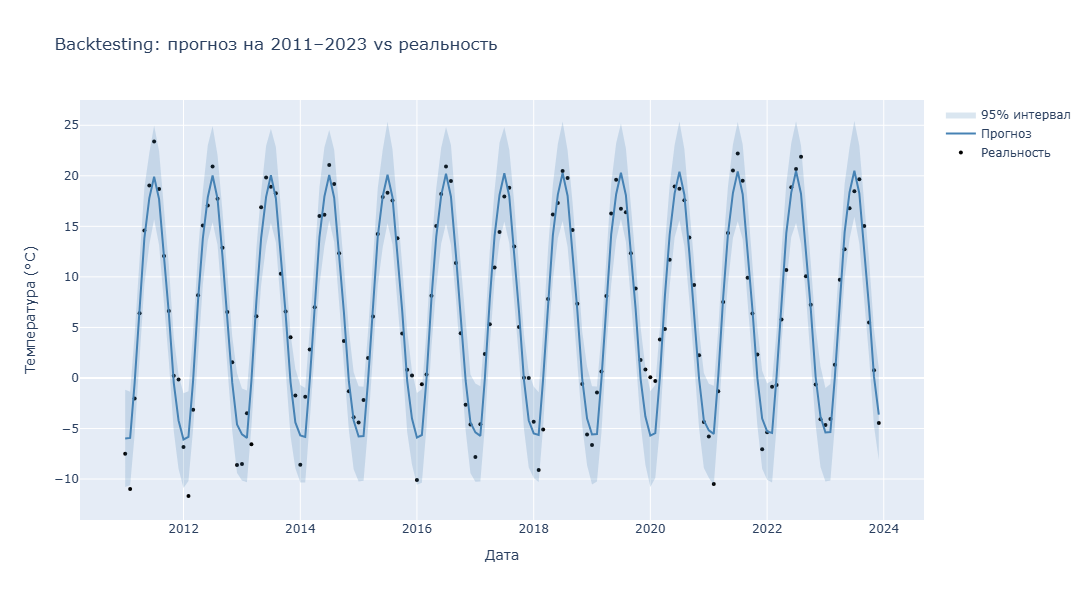

In [14]:
fig = go.Figure()

# Реальные данные
fig.add_trace(go.Scatter(
    x=test["ds"], y=test["y"],
    mode="markers", name="Реальность",
    marker=dict(color="black", size=4),
))

# Прогноз
fig.add_trace(go.Scatter(
    x=merged["ds"], y=merged["yhat"],
    mode="lines", name="Прогноз",
    line=dict(color="steelblue", width=2),
))

# 95% интервал
fig.add_trace(go.Scatter(
    x=merged["ds"], y=merged["yhat_upper"],
    mode="lines", line=dict(width=0), showlegend=False, hoverinfo="skip",
))
fig.add_trace(go.Scatter(
    x=merged["ds"], y=merged["yhat_lower"],
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(70,130,180,0.2)",
    name="95% интервал", hoverinfo="skip",
))

fig.update_layout(
    title="Backtesting: прогноз на 2011–2023 vs реальность",
    xaxis_title="Дата", yaxis_title="Температура (°C)",
    hovermode="x unified", height=600,
)
fig.show()

In [15]:
inside = ((merged["y"] >= merged["yhat_lower"]) & (merged["y"] <= merged["yhat_upper"])).mean()

print(f"Реальность внутри 95% интервала: {inside:.1%} месяцев")

Реальность внутри 95% интервала: 95.5% месяцев


In [16]:
from datasets import load_dataset

dataset = load_dataset("maxzt/RusWeather-434", split="train")
df_fresh = dataset.to_pandas()

print("Размер:", df_fresh.shape)
print()
print(df_fresh.head())
print()
print("Колонки:", df_fresh.columns.tolist())

ModuleNotFoundError: No module named 'datasets'

In [1]:
from datasets import load_dataset

dataset = load_dataset("maxzt/RusWeather-434", split="train")
df_fresh = dataset.to_pandas()

print("Размер:", df_fresh.shape)
print()
print(df_fresh.head())
print()
print("Колонки:", df_fresh.columns.tolist())

README.md:   0%|          | 0.00/13.1k [00:00<?, ?B/s]

russia_weather_434.parquet: reconstructing file:   0%|          |  0.00B / 23.8MB            

russia_weather_434.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Размер: (1197406, 16)

     city      lat      lon       date    T2M  T2M_MAX  T2M_MIN  T2MDEW  \
0  Abakan  53.7211  91.4433 2019-01-01 -18.02   -15.92   -20.45  -19.05   
1  Abakan  53.7211  91.4433 2019-01-02 -18.52   -15.55   -21.90  -18.97   
2  Abakan  53.7211  91.4433 2019-01-03 -20.65   -19.02   -22.75  -21.28   
3  Abakan  53.7211  91.4433 2019-01-04 -25.65   -22.77   -28.25  -25.86   
4  Abakan  53.7211  91.4433 2019-01-05 -21.90   -17.19   -26.28  -23.03   

    RH2M  PRECTOTCORR     PS  WS10M  WS10M_MAX  WS2M  ALLSKY_SFC_SW_DWN  \
0  93.21         1.10  98.97   1.09       1.74  0.73               3.13   
1  97.82         0.52  99.05   1.09       1.77  0.68               3.39   
2  94.39         0.08  99.24   0.79       1.52  0.52               3.52   
3  98.04         0.07  98.87   1.24       2.28  0.78               3.81   
4  90.99         0.05  98.60   2.05       4.73  1.14               3.46   

   CLOUD_AMT  
0      29.04  
1      32.12  
2      46.60  
3      15.24  


In [2]:
df_fresh["date"] = pd.to_datetime(df_fresh["date"])

df_moscow = df_fresh[df_fresh["city"] == "Moscow"].copy()
df_moscow = df_moscow.sort_values("date").reset_index(drop=True)

print("Строк по Москве:", len(df_moscow))
print("Дата от:", df_moscow["date"].min())
print("Дата до: ", df_moscow["date"].max())
print()
print(df_moscow[["date", "T2M"]].head())

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [4]:
# Загружаем исторический датасет RusWeather-GF
df = pd.read_csv("/app/RusWeather-GF/RusWeather-GF_1980-2023.csv")

# Фильтруем Москву
df_city = df[df["station_id"] == 27612].copy()
df_city["date"] = pd.to_datetime(df_city["date"])
df_city = df_city.sort_values("date").reset_index(drop=True)

# Агрегируем по месяцам
df_monthly = df_city.set_index("date").resample("MS")["temperature"].mean().reset_index()
df_monthly = df_monthly.rename(columns={"date": "ds", "temperature": "y"})

print("Месяцев истории:", len(df_monthly))

# Обучаем Prophet на всей истории 1980–2023
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
)
model.fit(df_monthly)

# Прогноз на 84 месяца вперёд (до 2030)
future = model.make_future_dataframe(periods=84, freq="MS")
forecast = model.predict(future)

print("Прогноз готов. Последняя дата:", forecast["ds"].max())

Месяцев истории: 528


14:14:15 - cmdstanpy - INFO - Chain [1] start processing
14:14:15 - cmdstanpy - INFO - Chain [1] done processing


Прогноз готов. Последняя дата: 2030-12-01 00:00:00


In [5]:
df_fresh["date"] = pd.to_datetime(df_fresh["date"])

df_moscow = df_fresh[df_fresh["city"] == "Moscow"].copy()
df_moscow = df_moscow.sort_values("date").reset_index(drop=True)

print("Строк по Москве:", len(df_moscow))
print("Дата от:", df_moscow["date"].min())
print("Дата до: ", df_moscow["date"].max())
print()
print(df_moscow[["date", "T2M", "T2M_MAX", "T2M_MIN"]].head())

Строк по Москве: 2759
Дата от: 2019-01-01 00:00:00
Дата до:  2026-07-21 00:00:00

        date    T2M  T2M_MAX  T2M_MIN
0 2019-01-01  -8.14    -5.33   -12.53
1 2019-01-02  -5.82    -4.78    -6.59
2 2019-01-03  -5.05    -4.60    -5.97
3 2019-01-04  -8.74    -5.83   -12.99
4 2019-01-05 -11.22    -8.27   -12.45


In [6]:
df_moscow_monthly = df_moscow.set_index("date").resample("MS")["T2M"].mean().reset_index()
df_moscow_monthly = df_moscow_monthly.rename(columns={"date": "ds", "T2M": "y_true"})

print("Всего месяцев:", len(df_moscow_monthly))
print()
print(df_moscow_monthly.tail(10))

Всего месяцев: 91

           ds     y_true
81 2025-10-01   5.317097
82 2025-11-01   0.806333
83 2025-12-01  -5.694516
84 2026-01-01 -13.510000
85 2026-02-01 -12.363571
86 2026-03-01  -0.509355
87 2026-04-01   4.146667
88 2026-05-01  13.865484
89 2026-06-01  17.211333
90 2026-07-01  18.952857


In [7]:
forecast_future = forecast[forecast["ds"] >= "2024-01-01"].copy()
forecast_future = forecast_future[forecast_future["ds"] <= "2026-07-01"].copy()

print("Месяцев прогноза:", len(forecast_future))
print(forecast_future[["ds", "yhat", "yhat_lower", "yhat_upper"]].head())

Месяцев прогноза: 31
            ds       yhat  yhat_lower  yhat_upper
528 2024-01-01  -5.608995  -10.219485   -0.605558
529 2024-02-01  -4.880758   -9.375216   -0.314833
530 2024-03-01   0.402507   -4.037599    4.958200
531 2024-04-01   8.169482    3.246443   12.931345
532 2024-05-01  14.461905    9.499103   19.367496


In [8]:
merged_fresh = df_moscow_monthly.merge(
    forecast_future[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="inner",
)

# Отбрасываем последний неполный месяц (июль 2026)
merged_fresh = merged_fresh[merged_fresh["ds"] < "2026-07-01"].reset_index(drop=True)

print("Месяцев для сравнения:", len(merged_fresh))
print()
print(merged_fresh.head(12).round(2))
print()
print("...")
print()
print(merged_fresh.tail(12).round(2))

Месяцев для сравнения: 30

           ds  y_true   yhat  yhat_lower  yhat_upper
0  2024-01-01  -15.09  -5.61      -10.22       -0.61
1  2024-02-01   -8.13  -4.88       -9.38       -0.31
2  2024-03-01   -3.36   0.40       -4.04        4.96
3  2024-04-01    7.83   8.17        3.25       12.93
4  2024-05-01   10.70  14.46        9.50       19.37
5  2024-06-01   18.94  18.50       14.02       23.26
6  2024-07-01   20.53  20.67       16.01       25.46
7  2024-08-01   18.01  18.63       14.03       23.02
8  2024-09-01   15.75  12.62        7.78       17.33
9  2024-10-01    5.95   6.99        2.22       11.59
10 2024-11-01   -1.10   0.64       -3.80        5.06
11 2024-12-01   -6.30  -3.98       -8.73        0.30

...

           ds  y_true   yhat  yhat_lower  yhat_upper
18 2025-07-01   20.11  20.66       16.11       25.29
19 2025-08-01   15.97  18.71       14.06       23.31
20 2025-09-01   12.20  12.80        8.65       17.10
21 2025-10-01    5.32   7.02        2.25       11.61
22 2025-11-01

/tmp/ipykernel_18/3161108161.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(merged_fresh.head(12).round(2))
/tmp/ipykernel_18/3161108161.py:16: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(merged_fresh.tail(12).round(2))


In [9]:
mae = mean_absolute_error(merged_fresh["y_true"], merged_fresh["yhat"])
rmse = np.sqrt(mean_squared_error(merged_fresh["y_true"], merged_fresh["yhat"]))
bias = (merged_fresh["yhat"] - merged_fresh["y_true"]).mean()
inside = ((merged_fresh["y_true"] >= merged_fresh["yhat_lower"]) &
          (merged_fresh["y_true"] <= merged_fresh["yhat_upper"])).mean()

print(f"MAE:  {mae:.2f}°C")
print(f"RMSE: {rmse:.2f}°C")
print(f"Bias: {bias:+.2f}°C")
print(f"Внутри 95% интервала: {inside:.1%} месяцев")

MAE:  2.52°C
RMSE: 3.49°C
Bias: +2.21°C
Внутри 95% интервала: 86.7% месяцев


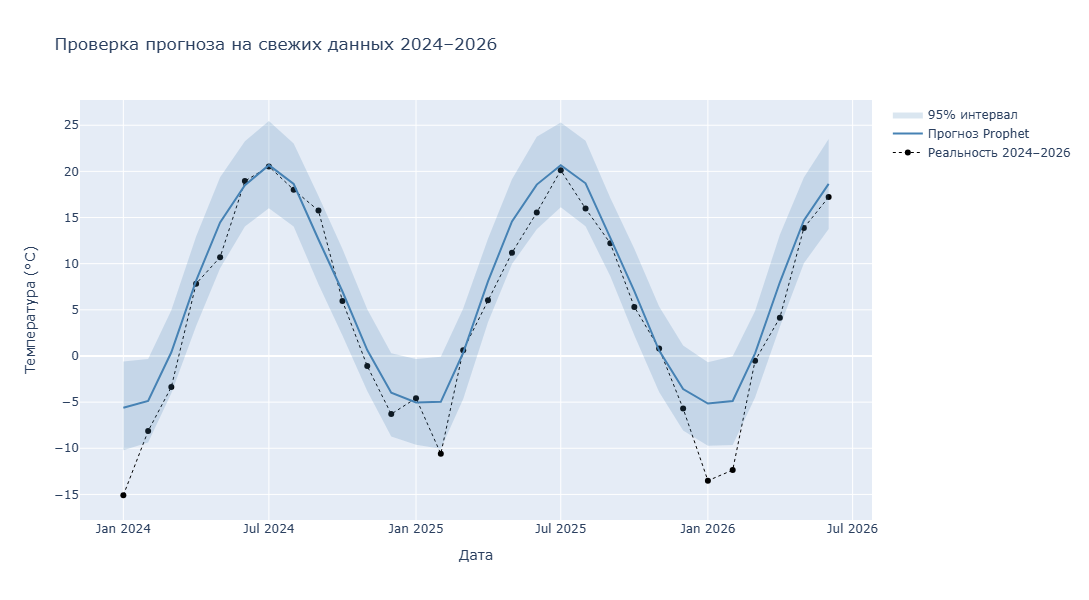

In [10]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=merged_fresh["ds"], y=merged_fresh["y_true"],
    mode="markers+lines", name="Реальность 2024–2026",
    marker=dict(color="black", size=6),
    line=dict(color="black", width=1, dash="dot"),
))

fig.add_trace(go.Scatter(
    x=merged_fresh["ds"], y=merged_fresh["yhat"],
    mode="lines", name="Прогноз Prophet",
    line=dict(color="steelblue", width=2),
))

fig.add_trace(go.Scatter(
    x=merged_fresh["ds"], y=merged_fresh["yhat_upper"],
    mode="lines", line=dict(width=0), showlegend=False, hoverinfo="skip",
))
fig.add_trace(go.Scatter(
    x=merged_fresh["ds"], y=merged_fresh["yhat_lower"],
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(70,130,180,0.2)",
    name="95% интервал", hoverinfo="skip",
))

fig.update_layout(
    title="Проверка прогноза на свежих данных 2024–2026",
    xaxis_title="Дата", yaxis_title="Температура (°C)",
    hovermode="x unified", height=600,
)
fig.show()

In [11]:
merged_fresh["year"] = merged_fresh["ds"].dt.year

errors_fresh = merged_fresh.groupby("year").apply(
    lambda g: pd.Series({
        "MAE": mean_absolute_error(g["y_true"], g["yhat"]),
        "bias": (g["yhat"] - g["y_true"]).mean(),
        "месяцев": len(g),
    })
).round(2)

print("Ошибка по годам (свежие данные):")
print(errors_fresh)

Ошибка по годам (свежие данные):
       MAE  bias  месяцев
year                     
2024  2.50  1.91     12.0
2025  1.89  1.74     12.0
2026  3.79  3.79      6.0


In [12]:
print("=== СРАВНЕНИЕ ===")
print()
print("Backtesting (2011–2023):")
print("  MAE ≈ 2.0°C, внутри интервала ≈ 95.5%")
print()
print("Свежие данные (2024–2026):")
print(f"  MAE = {mae:.2f}°C")
print(f"  Bias = {bias:+.2f}°C")
print(f"  Внутри интервала = {inside:.1%}")

=== СРАВНЕНИЕ ===

Backtesting (2011–2023):
  MAE ≈ 2.0°C, внутри интервала ≈ 95.5%

Свежие данные (2024–2026):
  MAE = 2.52°C
  Bias = +2.21°C
  Внутри интервала = 86.7%


In [13]:
# RusWeather-GF: Москва, 2019-2023
gf_recent = df_monthly[(df_monthly["ds"] >= "2019-01-01") & (df_monthly["ds"] <= "2023-12-31")].copy()
gf_recent = gf_recent.rename(columns={"y": "y_gf"})

# RusWeather-434: Москва, 2019-2023
fresh_recent = df_moscow_monthly[
    (df_moscow_monthly["ds"] >= "2019-01-01") & (df_moscow_monthly["ds"] <= "2023-12-31")
].copy()
fresh_recent = fresh_recent.rename(columns={"y_true": "y_fresh"})

# Сравниваем
compare = gf_recent.merge(fresh_recent, on="ds", how="inner")
compare["diff"] = compare["y_fresh"] - compare["y_gf"]

print("Месяцев для сравнения:", len(compare))
print()
print("Средняя разница (fresh - gf):", compare["diff"].mean().round(3), "°C")
print("Std разницы:", compare["diff"].std().round(3), "°C")
print("MAE между датасетами:", compare["diff"].abs().mean().round(3), "°C")
print()
print(compare.head(10).round(2))

Месяцев для сравнения: 60

Средняя разница (fresh - gf): -2.652 °C
Std разницы: 1.237 °C
MAE между датасетами: 2.652 °C

          ds   y_gf  y_fresh  diff
0 2019-01-01  -6.65   -10.72 -4.07
1 2019-02-01  -1.44    -5.01 -3.56
2 2019-03-01   0.65    -3.07 -3.71
3 2019-04-01   8.12     5.37 -2.75
4 2019-05-01  16.28    14.56 -1.72
5 2019-06-01  19.61    17.97 -1.65
6 2019-07-01  16.75    15.70 -1.05
7 2019-08-01  16.38    15.52 -0.86
8 2019-09-01  12.34    11.30 -1.04
9 2019-10-01   8.85     6.53 -2.33


/tmp/ipykernel_18/2017114276.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(compare.head(10).round(2))


In [14]:
# Берём историю до 2019 из GF
gf_old = df_monthly[df_monthly["ds"] < "2019-01-01"].copy()

# Берём 2019-2026 из свежего
fresh_all = df_moscow_monthly.copy()
fresh_all = fresh_all[fresh_all["ds"] < "2026-07-01"]  # отбрасываем неполный июль
fresh_all = fresh_all.rename(columns={"y_true": "y"})

# Объединяем
df_combined = pd.concat([gf_old, fresh_all], ignore_index=True).sort_values("ds").reset_index(drop=True)

print("Месяцев в объединённом датасете:", len(df_combined))
print("От:", df_combined["ds"].min())
print("До:", df_combined["ds"].max())
print()
print(df_combined.tail(10))

Месяцев в объединённом датасете: 558
От: 1980-01-01 00:00:00
До: 2026-06-01 00:00:00

            ds          y
548 2025-09-01  12.204667
549 2025-10-01   5.317097
550 2025-11-01   0.806333
551 2025-12-01  -5.694516
552 2026-01-01 -13.510000
553 2026-02-01 -12.363571
554 2026-03-01  -0.509355
555 2026-04-01   4.146667
556 2026-05-01  13.865484
557 2026-06-01  17.211333


In [15]:
model_v2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
)
model_v2.fit(df_combined)
print("Модель v2 обучена на 1980–2026")

14:20:42 - cmdstanpy - INFO - Chain [1] start processing
14:20:42 - cmdstanpy - INFO - Chain [1] done processing


Модель v2 обучена на 1980–2026


In [16]:
future_v2 = model_v2.make_future_dataframe(periods=54, freq="MS")  # до конца 2030 (54 мес от июля 2026)
forecast_v2 = model_v2.predict(future_v2)

# Прогноз на 2027–2030
print("Прогноз v2 на 2027–2030:")
print(forecast_v2[forecast_v2["ds"] >= "2027-01-01"][["ds", "yhat", "yhat_lower", "yhat_upper"]].head(12).round(2))

Прогноз v2 на 2027–2030:
            ds   yhat  yhat_lower  yhat_upper
564 2027-01-01  -8.54      -13.51       -4.09
565 2027-02-01  -7.75      -12.31       -3.00
566 2027-03-01  -2.65       -7.65        1.90
567 2027-04-01   4.94        0.20       10.14
568 2027-05-01  12.34        7.50       17.27
569 2027-06-01  16.10       11.15       20.70
570 2027-07-01  17.94       13.45       22.68
571 2027-08-01  16.29       11.67       21.09
572 2027-09-01  10.64        5.87       15.09
573 2027-10-01   4.33       -0.39        9.00
574 2027-11-01  -2.34       -6.51        2.26
575 2027-12-01  -5.44      -10.38       -0.54


/tmp/ipykernel_18/3777445982.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(forecast_v2[forecast_v2["ds"] >= "2027-01-01"][["ds", "yhat", "yhat_lower", "yhat_upper"]].head(12).round(2))


In [17]:
forecast_on_known = forecast_v2[forecast_v2["ds"].isin(fresh_all["ds"])].copy()

check = fresh_all.merge(
    forecast_on_known[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds", how="inner",
)

mae_v2 = mean_absolute_error(check["y"], check["yhat"])
bias_v2 = (check["yhat"] - check["y"]).mean()

print("На 2024–2026 (in-sample, модель их видела):")
print(f"  MAE:  {mae_v2:.2f}°C")
print(f"  Bias: {bias_v2:+.2f}°C")

На 2024–2026 (in-sample, модель их видела):
  MAE:  1.99°C
  Bias: +0.46°C


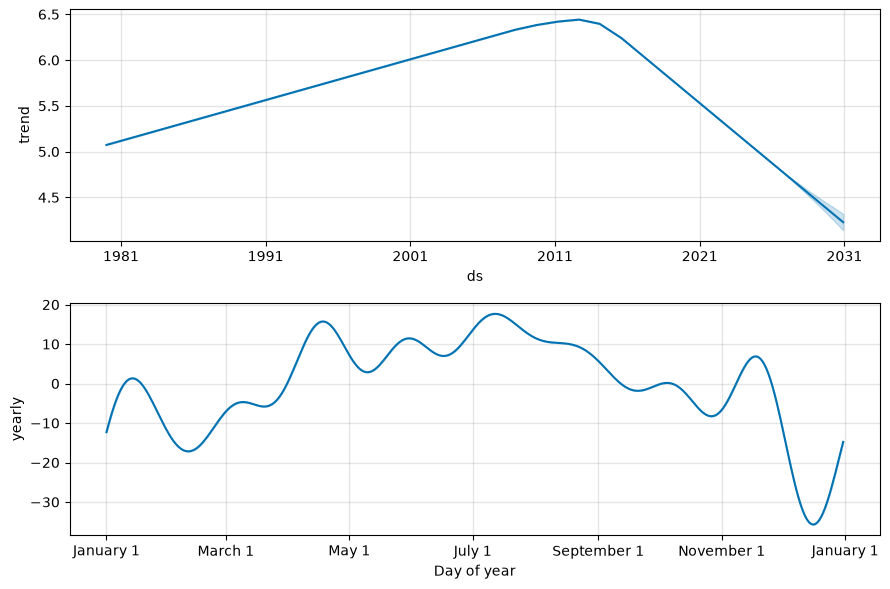

In [18]:
# Компоненты v2
fig2 = model_v2.plot_components(forecast_v2)
plt.tight_layout()
plt.show()

In [19]:
# Train до 2025-06
train_v3 = df_combined[df_combined["ds"] < "2025-07-01"].copy()

# Test: 2025-07 – 2026-06
test_v3 = df_combined[df_combined["ds"] >= "2025-07-01"].copy()

print("Train:", len(train_v3), "Test:", len(test_v3))

model_v3 = Prophet(
    yearly_seasonality=True, weekly_seasonality=False,
    daily_seasonality=False, interval_width=0.95,
)
model_v3.fit(train_v3)

future_v3 = model_v3.make_future_dataframe(periods=len(test_v3), freq="MS")
forecast_v3 = model_v3.predict(future_v3)

merged_v3 = test_v3.merge(
    forecast_v3[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds", how="inner",
)

mae_v3 = mean_absolute_error(merged_v3["y"], merged_v3["yhat"])
bias_v3 = (merged_v3["yhat"] - merged_v3["y"]).mean()
inside_v3 = ((merged_v3["y"] >= merged_v3["yhat_lower"]) &
             (merged_v3["y"] <= merged_v3["yhat_upper"])).mean()

print()
print("=== Hold-out проверка v3 (2025-07 – 2026-06) ===")
print(f"MAE:  {mae_v3:.2f}°C")
print(f"Bias: {bias_v3:+.2f}°C")
print(f"Внутри 95% интервала: {inside_v3:.1%}")

14:21:38 - cmdstanpy - INFO - Chain [1] start processing
14:21:38 - cmdstanpy - INFO - Chain [1] done processing


Train: 546 Test: 12

=== Hold-out проверка v3 (2025-07 – 2026-06) ===
MAE:  1.97°C
Bias: +0.07°C
Внутри 95% интервала: 91.7%


In [20]:
model_v4 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
    changepoint_prior_scale=0.01,   # ← ограничиваем гибкость тренда
)

14:24:45 - cmdstanpy - INFO - Chain [1] start processing
14:24:45 - cmdstanpy - INFO - Chain [1] done processing


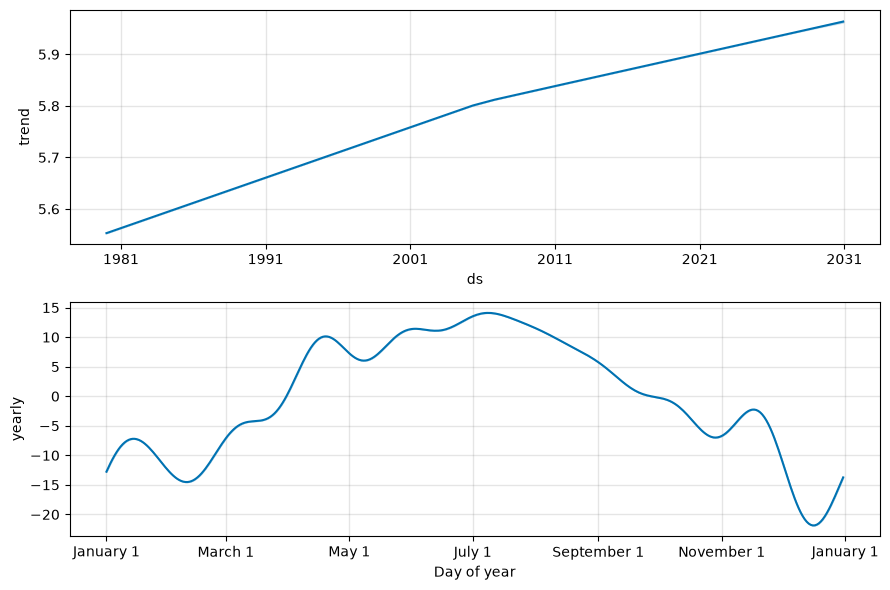

            ds   yhat  yhat_lower  yhat_upper
564 2027-01-01  -7.21      -12.12       -2.34
565 2027-02-01  -6.63      -11.64       -2.00
566 2027-03-01  -1.40       -6.12        3.39
567 2027-04-01   6.32        1.57       11.17
568 2027-05-01  13.35        8.27       18.03
569 2027-06-01  17.30       12.59       22.02
570 2027-07-01  19.40       14.70       24.07
571 2027-08-01  17.54       12.56       22.64
572 2027-09-01  11.83        7.11       16.71
573 2027-10-01   5.73        0.73       10.62
574 2027-11-01  -0.86       -5.48        4.04
575 2027-12-01  -4.62       -9.60        0.04


/tmp/ipykernel_18/1024861444.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(forecast_v4[forecast_v4["ds"] >= "2027-01-01"][["ds", "yhat", "yhat_lower", "yhat_upper"]].head(12).round(2))


In [21]:
model_v4 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
    changepoint_prior_scale=0.01,
)
model_v4.fit(df_combined)

future_v4 = model_v4.make_future_dataframe(periods=54, freq="MS")
forecast_v4 = model_v4.predict(future_v4)

fig4 = model_v4.plot_components(forecast_v4)
plt.tight_layout()
plt.show()

# Прогноз на 2030
print(forecast_v4[forecast_v4["ds"] >= "2027-01-01"][["ds", "yhat", "yhat_lower", "yhat_upper"]].head(12).round(2))

In [22]:
# Hold-out: обучаем на 1980 – июнь 2025, тестируем июль 2025 – июнь 2026
train_v4ho = df_combined[df_combined["ds"] < "2025-07-01"].copy()
test_v4ho = df_combined[df_combined["ds"] >= "2025-07-01"].copy()

model_v4ho = Prophet(
    yearly_seasonality=True, weekly_seasonality=False,
    daily_seasonality=False, interval_width=0.95,
    changepoint_prior_scale=0.01,
)
model_v4ho.fit(train_v4ho)

future_v4ho = model_v4ho.make_future_dataframe(periods=len(test_v4ho), freq="MS")
forecast_v4ho = model_v4ho.predict(future_v4ho)

merged_v4ho = test_v4ho.merge(
    forecast_v4ho[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds", how="inner",
)

mae_v4 = mean_absolute_error(merged_v4ho["y"], merged_v4ho["yhat"])
bias_v4 = (merged_v4ho["yhat"] - merged_v4ho["y"]).mean()
inside_v4 = ((merged_v4ho["y"] >= merged_v4ho["yhat_lower"]) &
             (merged_v4ho["y"] <= merged_v4ho["yhat_upper"])).mean()

print("=== Hold-out v4 (2025-07 – 2026-06) ===")
print(f"MAE:  {mae_v4:.2f}°C")
print(f"Bias: {bias_v4:+.2f}°C")
print(f"Внутри интервала: {inside_v4:.1%}")

14:26:37 - cmdstanpy - INFO - Chain [1] start processing
14:26:37 - cmdstanpy - INFO - Chain [1] done processing


=== Hold-out v4 (2025-07 – 2026-06) ===
MAE:  1.82°C
Bias: +1.24°C
Внутри интервала: 83.3%
